In [1]:
import numpy as np
import random
from tqdm.notebook import trange, tqdm

In [2]:
with open('text8') as f:
    corpus = f.read()[:10000].split()

In [3]:
len(corpus)

1603

In [4]:
vocab = set(corpus)

len(vocab)

628

In [5]:
word2i = {w: idx for idx, w in enumerate(vocab)}
i2word = {idx: w for idx, w in enumerate(vocab)}

In [6]:
word2i

{'culottes': 0,
 'wealth': 1,
 'wish': 2,
 'capitalism': 3,
 'yarros': 4,
 'interfering': 5,
 'as': 6,
 'being': 7,
 'amidst': 8,
 'property': 9,
 'answers': 10,
 'supported': 11,
 'profits': 12,
 'party': 13,
 'man': 14,
 'laws': 15,
 'provide': 16,
 'strongly': 17,
 'mean': 18,
 'ruling': 19,
 'doctrine': 20,
 'how': 21,
 'periodical': 22,
 'labor': 23,
 'bands': 24,
 'xiv': 25,
 'labour': 26,
 'commonly': 27,
 'time': 28,
 'lysander': 29,
 'destroy': 30,
 'accepted': 31,
 'although': 32,
 'bertrand': 33,
 'benjamin': 34,
 'nihilism': 35,
 'reality': 36,
 'communities': 37,
 'use': 38,
 'de': 39,
 'possession': 40,
 'and': 41,
 'difference': 42,
 'structures': 43,
 'individualistically': 44,
 'had': 45,
 'predecessors': 46,
 'ruler': 47,
 'governance': 48,
 'believe': 49,
 'karl': 50,
 'knows': 51,
 'individualist': 52,
 'held': 53,
 'has': 54,
 'what': 55,
 'spencer': 56,
 'inclined': 57,
 'internationals': 58,
 'century': 59,
 'egalitarian': 60,
 'used': 61,
 'he': 62,
 'abolished'

In [7]:
i2word

{0: 'culottes',
 1: 'wealth',
 2: 'wish',
 3: 'capitalism',
 4: 'yarros',
 5: 'interfering',
 6: 'as',
 7: 'being',
 8: 'amidst',
 9: 'property',
 10: 'answers',
 11: 'supported',
 12: 'profits',
 13: 'party',
 14: 'man',
 15: 'laws',
 16: 'provide',
 17: 'strongly',
 18: 'mean',
 19: 'ruling',
 20: 'doctrine',
 21: 'how',
 22: 'periodical',
 23: 'labor',
 24: 'bands',
 25: 'xiv',
 26: 'labour',
 27: 'commonly',
 28: 'time',
 29: 'lysander',
 30: 'destroy',
 31: 'accepted',
 32: 'although',
 33: 'bertrand',
 34: 'benjamin',
 35: 'nihilism',
 36: 'reality',
 37: 'communities',
 38: 'use',
 39: 'de',
 40: 'possession',
 41: 'and',
 42: 'difference',
 43: 'structures',
 44: 'individualistically',
 45: 'had',
 46: 'predecessors',
 47: 'ruler',
 48: 'governance',
 49: 'believe',
 50: 'karl',
 51: 'knows',
 52: 'individualist',
 53: 'held',
 54: 'has',
 55: 'what',
 56: 'spencer',
 57: 'inclined',
 58: 'internationals',
 59: 'century',
 60: 'egalitarian',
 61: 'used',
 62: 'he',
 63: 'abolis

In [8]:
sum = 0
countOfWord = [sum+1 for w in corpus]

In [9]:
unigramFrequencies = {w: corpus.count(w) for w in vocab}

In [10]:
weightedUnigramFrequencies = {}

In [11]:
for k, v in unigramFrequencies.items():
    weightedUnigramFrequencies[k] = (v ** 0.75) / (len(vocab) ** 0.75)

In [12]:
weightedUnigramFrequencies

{'culottes': 0.007971320430160137,
 'wealth': 0.007971320430160137,
 'wish': 0.007971320430160137,
 'capitalism': 0.007971320430160137,
 'yarros': 0.007971320430160137,
 'interfering': 0.007971320430160137,
 'as': 0.08912207176135466,
 'being': 0.007971320430160137,
 'amidst': 0.007971320430160137,
 'property': 0.05457425067899526,
 'answers': 0.007971320430160137,
 'supported': 0.013406109549120714,
 'profits': 0.007971320430160137,
 'party': 0.007971320430160137,
 'man': 0.013406109549120714,
 'laws': 0.007971320430160137,
 'provide': 0.007971320430160137,
 'strongly': 0.007971320430160137,
 'mean': 0.007971320430160137,
 'ruling': 0.007971320430160137,
 'doctrine': 0.007971320430160137,
 'how': 0.018170681173797824,
 'periodical': 0.013406109549120714,
 'labor': 0.0225462989247084,
 'bands': 0.007971320430160137,
 'xiv': 0.007971320430160137,
 'labour': 0.018170681173797824,
 'commonly': 0.013406109549120714,
 'time': 0.018170681173797824,
 'lysander': 0.007971320430160137,
 'destro

In [13]:
def sigmoid(m):
  return (1 / (1 + np.e ** (-m)))

In [14]:
# def backwardLoss(t, c, n, targetWordI, contextWordsI, negativeSamplesI, lr):
#     d = (np.mean(np.sum((c @ t.reshape(32, 3, 1)), 1)))
#     s = sigmoid(d)
#     posDer = (s - 1) * t
#     posLoss = np.log(s)
#     d = -(np.mean(np.sum((n @ t.reshape(32, 3, 1)), 1)))
#     s = sigmoid(d)
#     negDer = s * t
#     negLoss = np.log(s)

#     #backprop
#     print('c from backwardLoss func reshaped removed zeros', c.reshape(128, 3)[~np.all(c.reshape(128, 3)==0, axis=1)].shape)
#     print('sigmoid partPosDer from backwardLoss', sigmoid(c @ t.reshape(32, 3, 1)))
#     partPosDer = (sigmoid(c @ t.reshape(32, 3, 1)) - 1)
#     partPosDer.reshape(128, 1)[np.all(partPosDer.reshape(128, 1)==-0.5, axis=1)] = \
#         np.repeat([[0]], partPosDer.reshape(128, 1)[np.all(partPosDer.reshape(128, 1)==-0.5, axis=1)].shape[0], axis=0)
#     print('part pos der finding',partPosDer)
#     print('full part pos der', (lr * partPosDer * t.reshape(32, 1, 3)).reshape(128, 3))
#     C[contextWordsI] -= (lr * partPosDer * t.reshape(32, 1, 3)).reshape(128, 3)
#     partNegDer = sigmoid(n @ t.reshape(32, 3, 1))
#     C[negativeSamplesI] -= (lr * partNegDer * t.reshape(32, 1, 3)).reshape(256, 3)
#     W[targetWordI] -= lr * ((partPosDer.reshape(32, 1, 4) @ c).squeeze(axis=1) + (partNegDer.reshape(32, 1, 8) @ n).squeeze(axis=1))

#     return -(posLoss + negLoss)

In [15]:
# d = c @ t.reshape(32, dim_size, 1)
# print(d.shape)
# s = sigmoid(d)
# print(s.shape)
# posLoss = np.mean(np.log(s))

# print(posLoss)

In [16]:
# def backwardLoss(t, c, n, targetWordI, contextWordsI, negativeSamplesI, lr, dim_size):
#     c_flat = c.reshape(-1, c.shape[2])
#     mask = np.all(c_flat == 0, axis=1)  # shape: (32,)
#     c_rows_with_all_zeros = np.nonzero(mask)[0]
#     n_flat = n.reshape(-1, n.shape[2])
#     mask = np.all(n_flat == 0, axis=1)  # shape: (32,)
#     n_rows_with_all_zeros = np.nonzero(mask)[0]
    
    
#     d = c @ t.reshape(32, dim_size, 1)
#     s = sigmoid(d)
#     partPosDer = (s - 1) * t.reshape(32, 1, dim_size)
#     posLoss = np.mean(np.log(s))
#     d = -n @ t.reshape(32, dim_size, 1)
#     s = sigmoid(d)
#     partNegDer = s * t.reshape(32, 1, dim_size)
#     negLoss = np.mean(np.log(s))
#     # print(f"part pos der, part neg der: {partPosDer}, {partNegDer}")
#     #backprop
#     C[contextWordsI] -= (lr * np.delete(partPosDer.reshape(-1, partPosDer.shape[2]), c_rows_with_all_zeros, axis=0))
#     C[negativeSamplesI] -= (lr * np.delete(partNegDer.reshape(-1, partNegDer.shape[2]), n_rows_with_all_zeros, axis=0))
#     W[targetWordI] -= (lr * ())
    
#     # c_flatten = c.reshape(128, dim_size)[~np.all(c.reshape(128, dim_size) == 0.0, axis=1)]
#     # partPosDer = sigmoid(c_flatten @ t.reshape(dim_size, 32)) - 1
#     # PosDer = (partPosDer @ t.reshape(32, dim_size)) * lr
#     # C[contextWordsI] -= PosDer
#     # n_flatten = n.reshape(256, dim_size)[~np.all(n.reshape(256, dim_size) == 0.0, axis=1)]
#     # partNegDer = sigmoid(n_flatten @ t.reshape(dim_size, 32))
#     # NegDer = (partNegDer @ t.reshape(32, dim_size)) * lr
#     # C[negativeSamplesI] -= NegDer
#     # W[targetWordI] -= (lr * ((partPosDer.T @ c_flatten) + (partNegDer.T @ n_flatten)))

#     return -(posLoss + negLoss)


In [17]:
# WINDOW_SIZE = 2
# K = 2
# words = list(weightedUnigramFrequencies.keys())
# weights = list(weightedUnigramFrequencies.values())

# def SGNS(choices, dim_size):
#     targetWord = []
#     contextWordsM = []
#     negativeSamplesM = []
#     targetWordI = []
#     contextWordsI = []
#     negativeSamplesI = []
#     for idx in choices:
#         contextWordsPadded = np.zeros((4, dim_size))
#         negativeSamplesPadded  = np.zeros((8, dim_size))
#         targetWordI += [word2i[corpus[idx]]]

        
#         targetWord.append(W[word2i[corpus[idx]]])
#         contextWords = corpus[max(idx-WINDOW_SIZE, 0):max(idx, 0)] \
#                                 + corpus[idx+1:idx+WINDOW_SIZE+1]
#         sliceRange = C[[word2i[w] for w in contextWords]].shape[0]
#         contextWordsPadded[:sliceRange] = C[[word2i[w] for w in contextWords]]
#         contextWordsM.append(contextWordsPadded)
#         contextWordsI += [word2i[w] for w in contextWords]
#         negativeSamples = random.choices(words, weights=weights, \
#                                          k=len(contextWords)*K)
#         sliceRange = C[[word2i[w] for w in negativeSamples]].shape[0]
#         negativeSamplesPadded[:sliceRange] = C[[word2i[w] for w in negativeSamples]]
#         negativeSamplesM.append(negativeSamplesPadded)
#         negativeSamplesI += [word2i[w] for w in negativeSamples]
#     targetWord = np.stack(targetWord, axis=0)
#     contextWordsM = np.stack(contextWordsM, axis=0)
#     negativeSamplesM = np.stack(negativeSamplesM, axis=0)
    

#     return targetWord, contextWordsM, negativeSamplesM, targetWordI, contextWordsI, negativeSamplesI


In [18]:
# EPOCHS = 100
# ITERS = int(len(corpus) / 32)
# WINDOW_SIZE = 2
# K = 2
# dim_size = 100
# words = list(weightedUnigramFrequencies.keys())
# weights = list(weightedUnigramFrequencies.values())
# C = np.random.randn(len(vocab), dim_size)
# W = np.random.randn(len(vocab), dim_size)
# lr = 1e-6
# total_loss = 0.0

# for e in range(EPOCHS):
#   total_loss = 0.0
#   for i in range(ITERS):
#     choices = np.random.choice(np.arange(len(corpus)), 32)
#     t, c, n, tI, cI, nI = SGNS(choices, dim_size)
#     L = backwardLoss(t, c, n, tI, cI, nI, lr, dim_size=dim_size)
#     total_loss += L
#   print(f'Epoch: {e+1} {total_loss/ITERS}')


In [ ]:
WINDOW_SIZE = 2
K = 8
dim_size = 100
C = np.random.randn(len(vocab), dim_size)
W = np.random.randn(len(vocab), dim_size)
words = list(weightedUnigramFrequencies.keys())
weights = list(weightedUnigramFrequencies.values())
lr = 1e-3
running_loss = []

for e in trange(10000, desc="Epochs"):
    total_loss = 0.0
    for i, w in enumerate(corpus):
        #get target, context, negative samples
        t = w
        c = corpus[max(i-WINDOW_SIZE, 0):max(i, 0)] \
                                    + corpus[i+1:i+WINDOW_SIZE+1]
        n = random.choices(words, weights=weights, \
                                            k=len(c)*K)
        #get target, context, negative samples indices    
        tI = word2i[t]
        cI = [word2i[cw] for cw in c]
        nI = [word2i[nw] for nw in n]

        #get target, context, negaIve samples embeddings
        tE = W[tI]
        cE = C[cI]
        nE = C[nI]

        #calculate total loss
        pL = np.sum(np.log(sigmoid(cE @ tE)))
        nL = np.sum(np.log(sigmoid(-nE @ tE)))
        L = -(pL + nL)
        total_loss += L

        #derivaIve calculaIon
        lParDerC = (sigmoid(cE @ tE) - 1)
        lParDerN = (sigmoid(nE @ tE))
        lParDerT = np.sum(lParDerC[:, None] * cE, 0) + np.sum(lParDerN[:, None] * nE, 0)
        
        #backprop
        C[cI] -= lr * lParDerC[:, None] * tE
        C[nI] -= lr * lParDerN[:, None] * tE
        W[tI] -= lr * lParDerT
    avg_loss = total_loss / len(corpus)
    running_loss.append(avg_loss)
    print(f"Epoch {e+1} Loss: {total_loss/len(corpus)}")
    # tqdm.write(f"Epoch {e+1} Avg Loss: {avg_loss:.4f}")


Epochs:   0%|          | 0/10000 [00:00<?, ?it/s]

Epoch 1 Avg Loss: 143.0002
Epoch 2 Avg Loss: 135.7078
Epoch 3 Avg Loss: 127.5141
Epoch 4 Avg Loss: 123.2406
Epoch 5 Avg Loss: 118.3077
Epoch 6 Avg Loss: 115.1878
Epoch 7 Avg Loss: 109.5516
Epoch 8 Avg Loss: 108.4615
Epoch 9 Avg Loss: 103.3500
Epoch 10 Avg Loss: 102.2677
Epoch 11 Avg Loss: 98.8930
Epoch 12 Avg Loss: 97.6283
Epoch 13 Avg Loss: 94.1001
Epoch 14 Avg Loss: 91.2579
Epoch 15 Avg Loss: 90.2074
Epoch 16 Avg Loss: 88.4328
Epoch 17 Avg Loss: 86.7175
Epoch 18 Avg Loss: 85.5138
Epoch 19 Avg Loss: 82.1694
Epoch 20 Avg Loss: 81.3580
Epoch 21 Avg Loss: 80.5115
Epoch 22 Avg Loss: 77.7493
Epoch 23 Avg Loss: 76.5162
Epoch 24 Avg Loss: 75.3281
Epoch 25 Avg Loss: 73.0046
Epoch 26 Avg Loss: 73.4281
Epoch 27 Avg Loss: 70.6899
Epoch 28 Avg Loss: 69.6211
Epoch 29 Avg Loss: 68.1444
Epoch 30 Avg Loss: 66.7366
Epoch 31 Avg Loss: 66.0564
Epoch 32 Avg Loss: 63.6856
Epoch 33 Avg Loss: 64.1492
Epoch 34 Avg Loss: 62.4738


KeyboardInterrupt: 

In [311]:
embedding_matrix = C + W

In [318]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
embeddings_2d = tsne.fit_transform(embedding_matrix)

# Plot
def viz_nearest_words(nearest_words: list):
    plt.figure(figsize=(12, 8))
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.7)

    # Optional: annotate a few points
    for i, word in enumerate(nearest_words):  # annotate only first 50 for clarity
        plt.annotate(word, (embeddings_2d[word2i[word], 0], embeddings_2d[word2i[word], 1]))

    plt.title("t-SNE projection of Embeddings")
    plt.show()


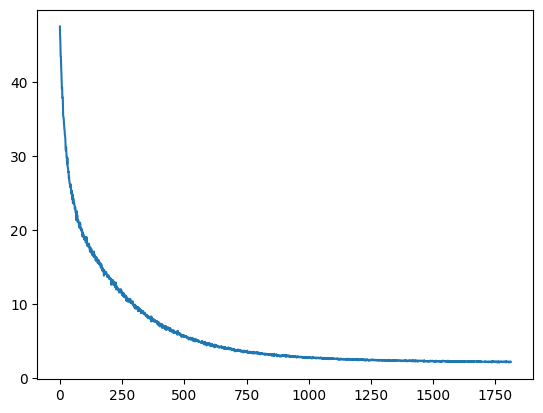

In [244]:
plt.plot(running_loss)

In [312]:
def top_nearest_words(source_word: str, num: int):
  nearest_words = []
  scores = (embedding_matrix @ embedding_matrix[word2i[source_word]])
  top_idx = np.argsort(scores)[::-1][:num]  # indices of top 10 values
  top_vals = scores[top_idx]
  for idx in top_idx:
    nearest_words.append(i2word[idx])
  return nearest_words
  

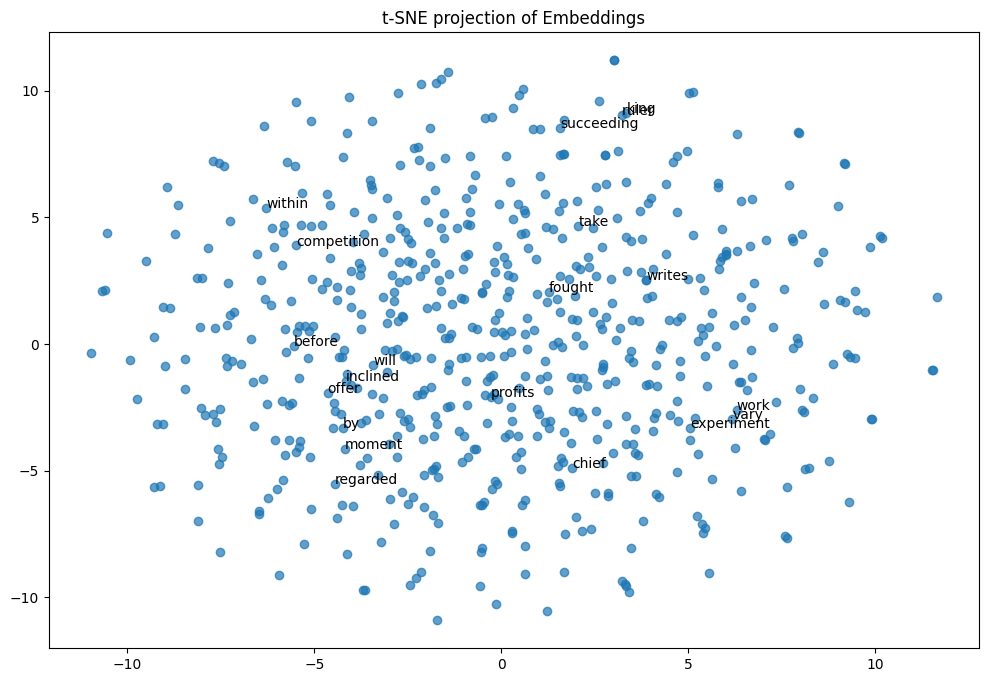

In [324]:
viz_nearest_words(top_nearest_words('king', 20))